Loading Data, Cleaning, and Basic Visualizations

In [49]:
#Import Modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

<h1>HRSA Mental Health Dataset Availability</h1>

In [50]:
hrsa_df = pd.read_csv("BCD_HPSA_FCT_DET_MH.csv")

hrsa_df.head()

C:\Users\ConnerMorgan\AppData\Local\Temp\ipykernel_6788\3337126284.py:1: DtypeWarning: Columns (0: BHCMIS Organization Identification Number) have mixed types. Specify dtype option on import or set low_memory=False.
  hrsa_df = pd.read_csv("BCD_HPSA_FCT_DET_MH.csv")


,HPSA Name,HPSA ID,Designation Type,HPSA Discipline Class,HPSA Score,Primary State Abbreviation,HPSA Status,HPSA Designation Date,HPSA Designation Last Update Date,Metropolitan Indicator,...,Rural Status Code,State Abbreviation,State and County Federal Information Processing Standard Code,State FIPS Code,State Name,U.S. - Mexico Border 100 Kilometer Indicator,U.S. - Mexico Border County Indicator,Data Warehouse Record Create Date,Data Warehouse Record Create Date Text,Unnamed: 64
0,Low Income - St. John/St. Thomas,7789997804,HPSA Population,Mental Health,0,VI,Withdrawn,10/20/2005,10/30/2008,Non-Metropolitan,...,R,VI,78020,78,U.S. Virgin Islands,N,N,04/16/2026,2026/04/16,NaN
1,Low Income - St. John/St. Thomas,7789997804,HPSA Population,Mental Health,0,VI,Withdrawn,10/20/2005,10/30/2008,Non-Metropolitan,...,R,VI,78030,78,U.S. Virgin Islands,N,N,04/16/2026,2026/04/16,NaN
2,ST THOMAS EAST END MEDICAL CENTER CORPORATION,7789997803,Federally Qualified Health Center,Mental Health,23,VI,Designated,10/26/2002,09/22/2025,Non-Metropolitan,...,R,VI,78030,78,U.S. Virgin Islands,N,N,04/16/2026,2026/04/16,NaN
3,FREDERIKSTED HEALTH CARE INC,7789997802,Federally Qualified Health Center,Mental Health,22,VI,Designated,10/26/2002,09/22/2025,Non-Metropolitan,...,R,VI,78010,78,U.S. Virgin Islands,N,N,04/16/2026,2026/04/16,NaN
4,St. John Island,7788997414,High Needs Geographic HPSA,Mental Health,12,VI,Designated,09/02/2022,09/02/2022,Unknown,...,R,VI,78020,78,U.S. Virgin Islands,N,N,04/16/2026,2026/04/16,NaN


In [51]:
# remove empty columns
hrsa_df = hrsa_df.loc[:, ~hrsa_df.columns.str.contains('^Unnamed')]

# filter for Ohio
hrsa_ohio = hrsa_df[hrsa_df['state'] == 'OH'].copy()

# check data
hrsa_ohio.head()


KeyError: 'state'

In [ ]:
hrsa_county_ohio = hrsa_ohio.groupby(['fips', 'county', 'state']).agg({
    'hpsa_score': 'mean',
    'population_in_shortage': 'sum',
    'provider_shortage': 'sum'
}).reset_index()

hrsa_county_ohio.head(10)

,fips,county,state,hpsa_score,population_in_shortage,provider_shortage
0,39001,"Adams County, OH",OH,16.000000,390606.0,3.8700
1,39003,"Allen County, OH",OH,10.333333,449466.0,6.3714
2,39007,"Ashtabula County, OH",OH,13.333333,231618.0,5.7742
3,39009,"Athens County, OH",OH,16.666667,179640.0,5.7473
4,39011,"Auglaize County, OH",OH,9.500000,229299.0,5.2314
5,39013,"Belmont County, OH",OH,15.750000,87540.0,6.1500
6,39015,"Brown County, OH",OH,14.600000,725622.0,2.1500
7,39017,"Butler County, OH",OH,17.000000,77063.0,0.0000
8,39019,"Carroll County, OH",OH,16.000000,117600.0,7.5900
9,39021,"Champaign County, OH",OH,12.000000,83850.0,2.5150


First Visualization:
This bar chart shows the top 10 counties in Ohio with the highest mental health provider shortages. The visualization highlights significant variation in access to mental health services across counties. Some counties experience substantially higher shortages, indicating potential gaps in service availability and unequal distribution of mental health resources.

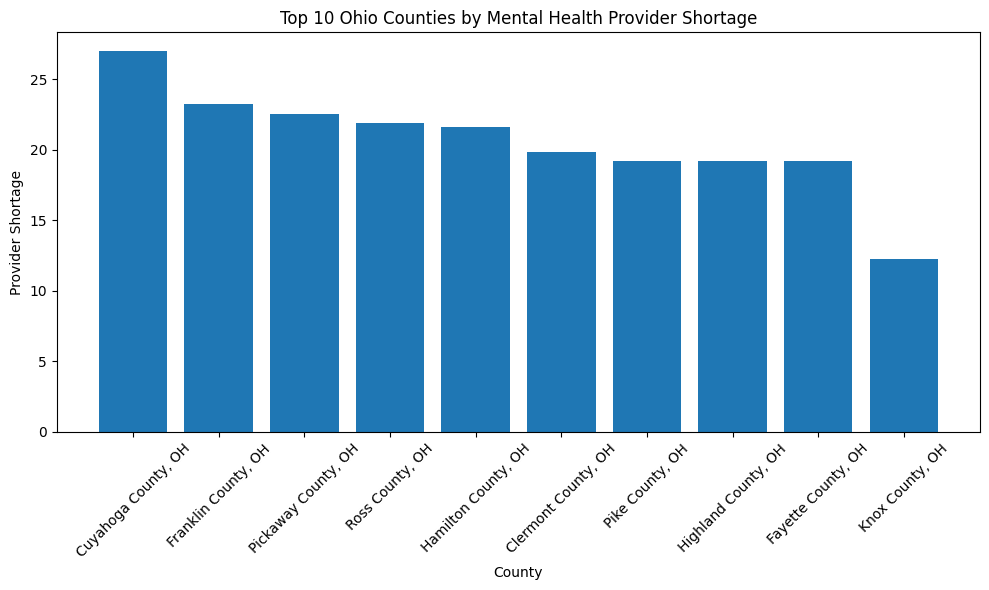

In [ ]:

# Sort and take top 10 counties
top_shortage = hrsa_county_ohio.sort_values(
    by='provider_shortage', ascending=False
).head(10)

# Create bar chart
plt.figure(figsize=(10,6))
plt.bar(top_shortage['county'], top_shortage['provider_shortage'])

plt.title('Top 10 Ohio Counties by Mental Health Provider Shortage')
plt.xlabel('County')
plt.ylabel('Provider Shortage')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<h1>CDC</h1>

In [ ]:
#read data 
places_df = pd.read_csv("PLACES__County_Data_(GIS_Friendly_Format),_2025_release_20260419.csv")

In [ ]:

#filter to ohio
places_ohio = places_df[places_df['StateAbbr'] == 'OH'].copy()

In [ ]:
#Cleaing the columns I need for the analysis
places_clean = places_ohio[[
    'CountyFIPS',
    'CountyName',
    'StateAbbr',
    'MHLTH_CrudePrev'
]].copy()

#Rename to match previous data set
places_clean = places_clean.rename(columns={
    'CountyFIPS': 'fips',
    'CountyName': 'county',
    'StateAbbr': 'state',
    'MHLTH_CrudePrev': 'mental_health_rate'
})

#make mips match previous data set for merging  
places_clean['fips'] = places_clean['fips'].astype(str).str.zfill(5)

places_clean.head()

,fips,county,state,mental_health_rate
24,39099,Mahoning,OH,17.6
45,39129,Pickaway,OH,18.5
46,39173,Wood,OH,17.4
51,39055,Geauga,OH,15.2
109,39065,Hardin,OH,19.9


In [ ]:
#merge data sets
merged_df = hrsa_county_ohio.merge(
    places_clean,
    on='fips',
    how='inner'
)

merged_df.head()

,fips,county_x,state_x,hpsa_score,population_in_shortage,provider_shortage,county_y,state_y,mental_health_rate
0,39001,"Adams County, OH",OH,16.000000,390606.0,3.8700,Adams,OH,19.8
1,39003,"Allen County, OH",OH,10.333333,449466.0,6.3714,Allen,OH,18.3
2,39007,"Ashtabula County, OH",OH,13.333333,231618.0,5.7742,Ashtabula,OH,19.5
3,39009,"Athens County, OH",OH,16.666667,179640.0,5.7473,Athens,OH,20.9
4,39011,"Auglaize County, OH",OH,9.500000,229299.0,5.2314,Auglaize,OH,17.2


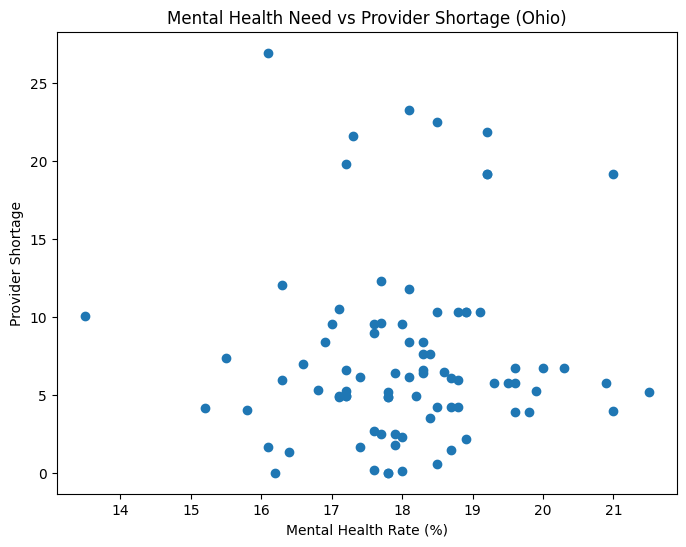

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    merged_df['mental_health_rate'],
    merged_df['provider_shortage']
)

plt.xlabel('Mental Health Rate (%)')
plt.ylabel('Provider Shortage')
plt.title('Mental Health Need vs Provider Shortage (Ohio)')

plt.show()

Visual 2: 
This scatter plot shows the relationship between mental health need and provider shortage across Ohio counties. The data does not show a strong relationship, as counties with similar mental health rates often have very different levels of provider shortage. This suggests that access to mental health services is not evenly distributed. Some counties experience both high mental health need and high provider shortages, indicating potential gaps in care.

<h1>ACS</h1>
ACS Data Processing
The American Community Survey (ACS) data was retrieved using the Census API to obtain population estimates for Ohio counties. The dataset was cleaned by renaming columns, converting population values to numeric format, and creating a standardized 5-digit FIPS code for merging. Only relevant columns were retained to support calculation of provider shortage per 100,000 residents.

In [ ]:

# Pull ACS 5-year data for Ohio counties using the Census API
url = (
    "https://api.census.gov/data/2024/acs/acs5"
    "?get=NAME,B01003_001E"
    "&for=county:*"
    "&in=state:39"
)
#The state 39 = Ohio
#Name B01003_001E = Total Population

acs_df = pd.read_json(url)

acs_df.columns = acs_df.iloc[0]
acs_df = acs_df[1:].copy()

acs_df = acs_df.rename(columns={
    "NAME": "county_name",        #Full country name
    "B01003_001E": "population",  #Total Population
    "state": "state_fips",        #State Fips code 
    "county": "county_fips"       #County Fips code 
})

acs_df["population"] = pd.to_numeric(acs_df["population"])
acs_df["fips"] = acs_df["state_fips"] + acs_df["county_fips"]

acs_df.head()

,county_name,population,state_fips,county_fips,fips
1,"Adams County, Ohio",27540,39,001,39001
2,"Allen County, Ohio",101348,39,003,39003
3,"Ashland County, Ohio",52256,39,005,39005
4,"Ashtabula County, Ohio",97167,39,007,39007
5,"Athens County, Ohio",61737,39,009,39009


In [ ]:
# Keep only necessary columns for analysis
acs_clean = acs_df[['fips', 'county_name', 'population']].copy()

# Ensure FIPS codes are formatted correctly (5 digits with leading zeros)
acs_clean['fips'] = acs_clean['fips'].astype(str).str.zfill(5)

# Preview cleaned dataset
acs_clean.head()

,fips,county_name,population
1,39001,"Adams County, Ohio",27540
2,39003,"Allen County, Ohio",101348
3,39005,"Ashland County, Ohio",52256
4,39007,"Ashtabula County, Ohio",97167
5,39009,"Athens County, Ohio",61737


In [ ]:
# Keep only necessary columns for analysis
acs_clean = acs_df[['fips', 'county_name', 'population']].copy()

# Ensure FIPS codes are formatted correctly (5 digits with leading zeros) Necessary for merging with other datasets
acs_clean['fips'] = acs_clean['fips'].astype(str).str.zfill(5)

# Preview cleaned dataset
acs_clean.head()

,fips,county_name,population
1,39001,"Adams County, Ohio",27540
2,39003,"Allen County, Ohio",101348
3,39005,"Ashland County, Ohio",52256
4,39007,"Ashtabula County, Ohio",97167
5,39009,"Athens County, Ohio",61737


In [ ]:
#merging the cdc with the hrsa
merged_df = hrsa_county_ohio.merge(
    places_clean,
    on='fips',
    how='inner'
)

merged_df.head()


,fips,county_x,state_x,hpsa_score,population_in_shortage,provider_shortage,county_y,state_y,mental_health_rate
0,39001,"Adams County, OH",OH,16.000000,390606.0,3.8700,Adams,OH,19.8
1,39003,"Allen County, OH",OH,10.333333,449466.0,6.3714,Allen,OH,18.3
2,39007,"Ashtabula County, OH",OH,13.333333,231618.0,5.7742,Ashtabula,OH,19.5
3,39009,"Athens County, OH",OH,16.666667,179640.0,5.7473,Athens,OH,20.9
4,39011,"Auglaize County, OH",OH,9.500000,229299.0,5.2314,Auglaize,OH,17.2


In [56]:
# merging all three together
merged_all = merged_df.merge(
    acs_clean,
    on='fips',
    how='inner'
)

merged_all.head()

,fips,county_x,state_x,hpsa_score,population_in_shortage,provider_shortage,county_y,state_y,mental_health_rate,county_name,population
0,39001,"Adams County, OH",OH,16.000000,390606.0,3.8700,Adams,OH,19.8,"Adams County, Ohio",27540
1,39003,"Allen County, OH",OH,10.333333,449466.0,6.3714,Allen,OH,18.3,"Allen County, Ohio",101348
2,39007,"Ashtabula County, OH",OH,13.333333,231618.0,5.7742,Ashtabula,OH,19.5,"Ashtabula County, Ohio",97167
3,39009,"Athens County, OH",OH,16.666667,179640.0,5.7473,Athens,OH,20.9,"Athens County, Ohio",61737
4,39011,"Auglaize County, OH",OH,9.500000,229299.0,5.2314,Auglaize,OH,17.2,"Auglaize County, Ohio",46125


In [ ]:
#checking the merge wroked
merged_all.shape
merged_all.columns

Index(['fips', 'county_x', 'state_x', 'hpsa_score', 'population_in_shortage',
       'provider_shortage', 'county_y', 'state_y', 'mental_health_rate',
       'county_name', 'population'],
      dtype='str')

In [58]:
merged_all['shortage_per_100k'] = (
    merged_all['provider_shortage'] / merged_all['population']
) * 100000

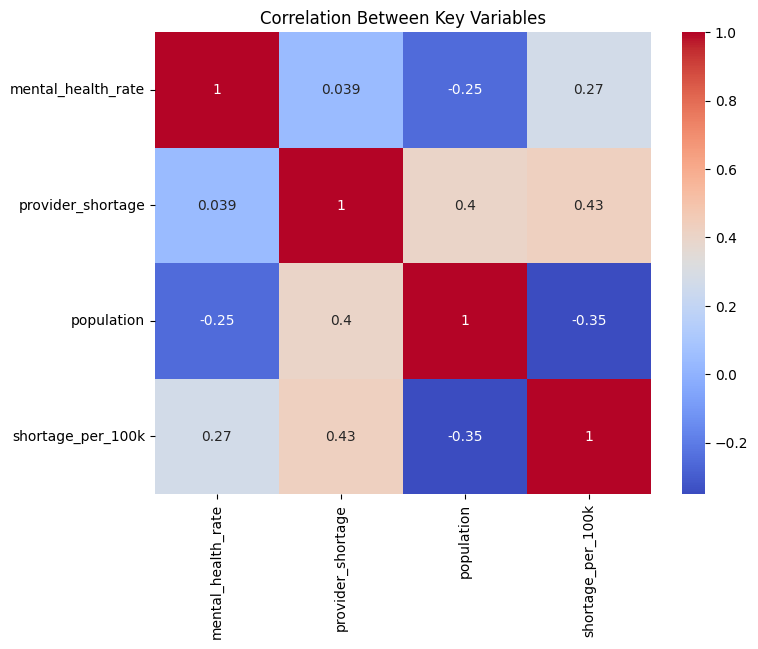

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    merged_all[['mental_health_rate', 'provider_shortage', 'population', 'shortage_per_100k']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Between Key Variables')

plt.show()

This heatmap shows the correlation between key variables in the dataset. Mental health rate and provider shortage do not show a strong correlation, suggesting that higher mental health need does not always correspond to higher provider availability. Population is also not strongly correlated with shortage per 100,000, reinforcing the importance of using normalized measures when comparing counties.

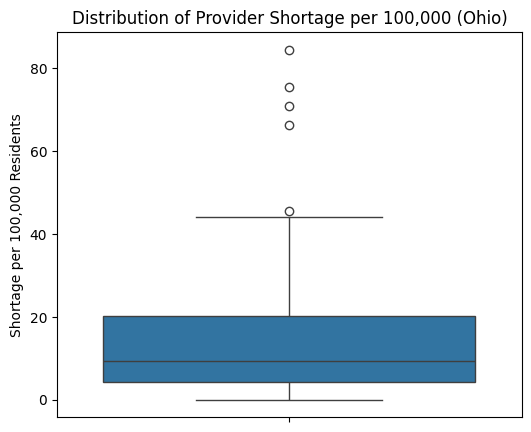

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.boxplot(y=merged_all['shortage_per_100k'])

plt.title('Distribution of Provider Shortage per 100,000 (Ohio)')
plt.ylabel('Shortage per 100,000 Residents')

plt.show()

This boxplot shows the distribution of provider shortage per 100,000 residents across Ohio counties. Most counties fall within a similar range, but several outliers are present with significantly higher shortages. These outliers are important to retain in the analysis, as they represent counties with potentially severe gaps in mental health service access.

In [62]:
!jupyter nbconvert --to python check2.ipynb

[NbConvertApp] Converting notebook check2.ipynb to python
[NbConvertApp] Writing 3880 bytes to check2.py
